In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
import torch
import GCN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import dense_to_sparse
from torch_geometric.data import Data

import importlib
import os
importlib.reload(GCN)

def plot_or_save(label1, label2, version, save = False):

    if not os.path.exists(f'filtered_data/{label1}_{label2}_X_val.npy'):
        raise FileNotFoundError(f"Label not founnd")


    if save:
        folder_path = f'pictures/{label1}_{label2}'
        os.makedirs(folder_path, exist_ok=True)


    types = ['val', 'train']
    error = [0, 0]
    data = [None]*4
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    for index, t_val in enumerate(types):

        # Load validation data
        data_x = np.load(f'filtered_data/{label1}_{label2}_X_{t_val}.npy')
        data_adj = np.load(f'filtered_data/{label1}_{label2}_adj_{t_val}.npy')
        data_y = np.load(f'filtered_data/{label1}_{label2}_y_{t_val}.npy')

        norm = np.load(f'filtered_data/{label1}_{label2}_norm_params.npy')

        # Convert to tensors
        device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
        X_val_tensor = torch.tensor(data_x, dtype=torch.float).to(device)
        adj_val_tensor = torch.tensor(data_adj, dtype=torch.float).to(device)
        y_val_tensor = torch.tensor(data_y, dtype=torch.float).to(device)

        model = GCN.GraphConv(19, 0.001).to(device)
        model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_location=device))
        model.eval()


        # Prepare validation dataset for prediction
        val_graphs = []
        for i in range(len(X_val_tensor)):
            edge_index, _ = dense_to_sparse(adj_val_tensor[i, :GCN.GRAPH_SIZE, :GCN.GRAPH_SIZE])
            data = Data(x=X_val_tensor[i, :GCN.GRAPH_SIZE], edge_index=edge_index)
            val_graphs.append(data)

        # Predict on validation set
        preds = []
        with torch.no_grad():
            for data in val_graphs:
                x = data.x
                edge_index = data.edge_index
                batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
                pred = model(x, data.edge_index, data.edge_weight, batch)
                preds.append(pred.cpu().numpy().flatten()[0])
                #preds.append(0.5)

        preds = np.array(preds)
        y_true = y_val_tensor.cpu().numpy().flatten()

        converted_preds = preds * (norm[1] - norm[0]) + norm[0]
        converted_y_true = y_true * (norm[1] - norm[0]) + norm[0]

        #data[index * 2 + 0] = preds
        #data[index * 2 + 1] = y_true
    
        ax = axes[index]
        sns.scatterplot(x=converted_y_true, y=converted_preds, ax=ax)
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.set_title(f'Predicted vs Actual for {label1}_{label2} ({t_val})')
        ax.plot([converted_y_true.min(), converted_y_true.max()], [converted_preds.min(), converted_preds.max()], 'r--')
        
        residuals = preds - y_true

        error[index] = np.mean(residuals**2)  # RMSE in original scale

    if save:
        plt.savefig(f'pictures/{label1}_{label2}/corr_{version}.png', dpi=300)

    plt.show()

        # Plot residuals
    fig_res, axes_res = plt.subplots(1, 2, figsize=(14, 7))

    # Plot residuals
    sns.histplot(residuals, bins=100, kde=True, ax=axes_res[0])
    axes_res[0].set_xlabel('Residual (Predicted - Actual)')
    axes_res[0].set_title(f'Residuals for {label1}_{label2}')

    # Plot actual data distribution
    sns.histplot(y_true, bins=100, kde=True, ax=axes_res[1])
    axes_res[1].set_xlabel('Actual Values')
    axes_res[1].set_title(f'Actual Data Distribution for {label1}_{label2}')

    plt.tight_layout()

    if save:
        plt.savefig(f'pictures/{label1}_{label2}/residuals_{version}.png', dpi=300)

    plt.show()

    amount = len(y_true)

    random_guess_error = 0
    for i in range(amount):
        random_guess = np.random.uniform(0, 1)
        random_guess_error += (random_guess - y_true[i])**2

    random_guess_error /= amount

    prediction_power_val = random_guess_error / error[0]  # Using validation RMSE
    prediction_power_train = random_guess_error / error[1]  # Using training RMSE
    

    # Bar plot of prediction power
    fig_power, ax_power = plt.subplots(figsize=(6, 6))
    ax_power.bar(['Baseline'], [1], color='lightgray', alpha=0.7, label='Baseline')
    ax_power.bar(['Prediction Power (Val)'], [prediction_power_val], color='skyblue', label='Model (Val)')
    ax_power.bar(['Prediction Power (Train)'], [prediction_power_train], color='lightgreen', label='Model (Train)')
    ax_power.set_ylabel('Prediction Power')
    ax_power.set_title(f'Prediction Power for {label1}_{label2}')
    ax_power.legend()
    plt.tight_layout()
    if save:
        plt.savefig(f'pictures/{label1}_{label2}/power_{version}.png', dpi=300)
    plt.show()



    

/tmp/ipykernel_1014/2751045255.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./models/model_{label1}_{label2}{version}.pt', map_loc

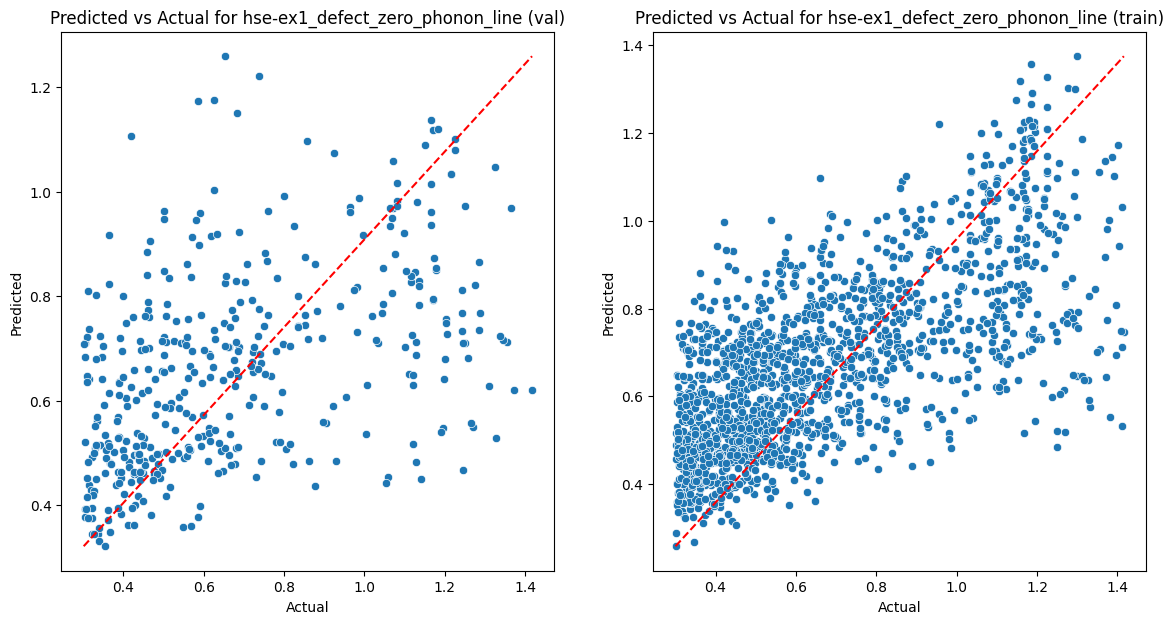

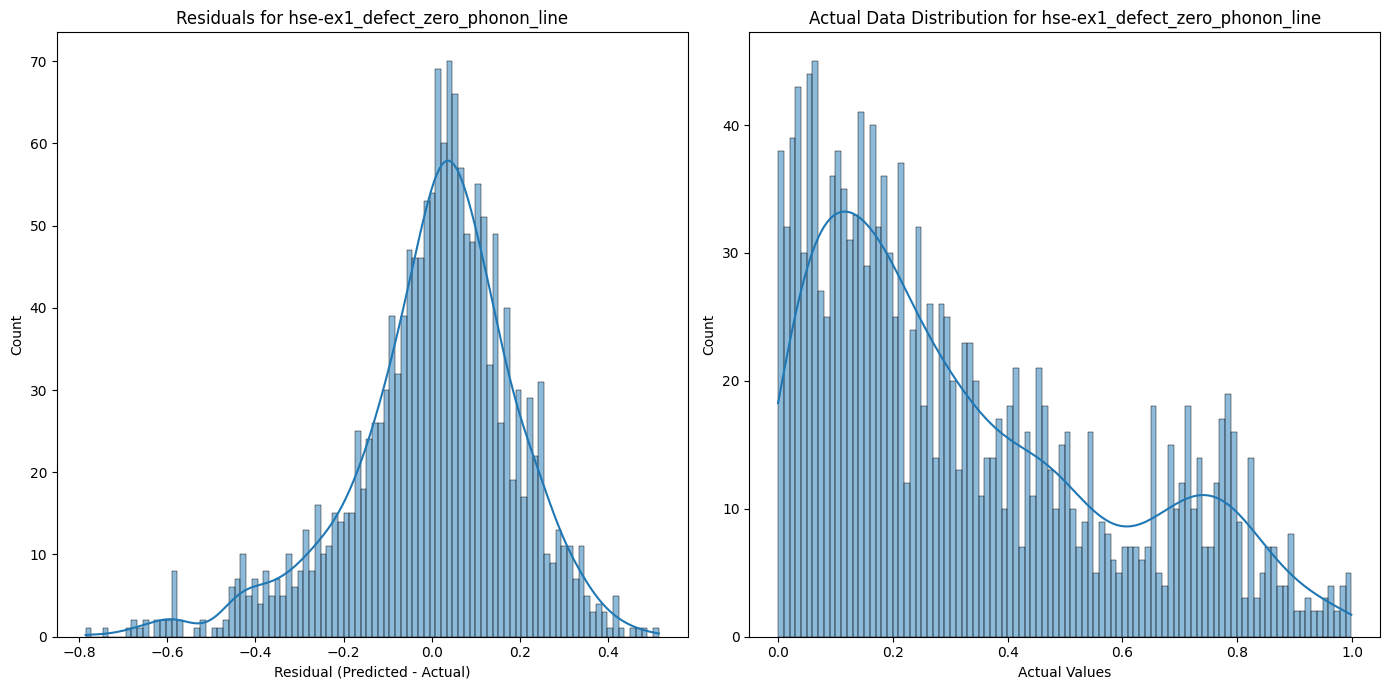

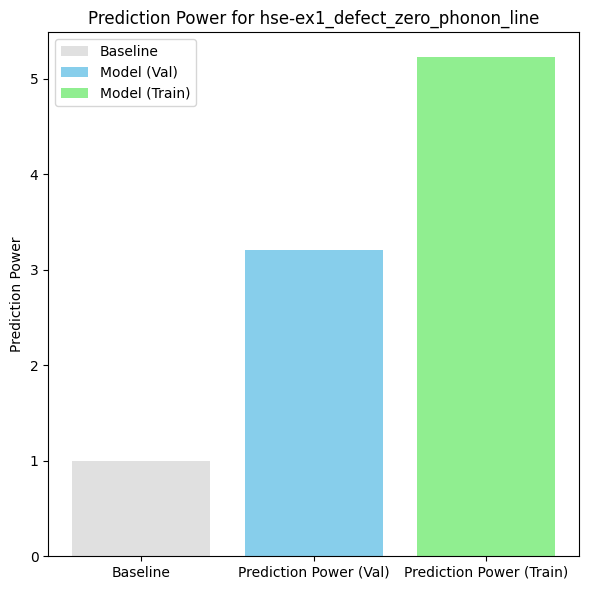

In [47]:

plot_or_save('hse-ex1', 'defect_zero_phonon_line', "4.0", save=True)